<a href="https://colab.research.google.com/github/Thomas-ds1/Kaggle/blob/main/CareerCon_Navigate_Robot/script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compétition 

In [1]:
!git clone https://github.com/Thomas-ds1/Kaggle.git

Cloning into 'Kaggle'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 37 (delta 5), reused 13 (delta 0), pack-reused 0
Unpacking objects: 100% (37/37), done.


# Modules 

In [5]:
# Import Dependencies
%matplotlib inline

# Start Python Imports
import math, time, random, datetime

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt
import missingno
import seaborn as sns
plt.style.use('seaborn-whitegrid')

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize

# Machine learning
import catboost
from sklearn.model_selection import train_test_split
from sklearn import model_selection, tree, preprocessing, metrics, linear_model
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier, Pool, cv

# Let's be rebels and ignore warnings for now
import warnings
warnings.filterwarnings('ignore')

# Loading Data 

In [256]:
X_train = pd.read_csv('/content/Kaggle/CareerCon_Navigate_Robot/DATA/X_test.csv')
X_test = pd.read_csv('/content/Kaggle/CareerCon_Navigate_Robot/DATA/y_train.csv')
sample_df = pd.read_csv('/content/Kaggle/CareerCon_Navigate_Robot/DATA/sample_submission.csv')

In [77]:
y_train.head()

,series_id,group_id,surface
0,0,13,fine_concrete
1,1,31,concrete
2,2,20,concrete
3,3,31,concrete
4,4,22,soft_tiles


In [78]:
X_train

,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z
0,0_0,0,0,0.91208,-0.38193,-0.050618,0.14028,-0.060205,0.071286,-0.187870,0.29492,2.8027,-9.6816
1,0_1,0,1,0.91220,-0.38165,-0.050573,0.14028,-0.033486,0.060210,-0.182060,0.14944,2.5408,-9.8521
2,0_2,0,2,0.91228,-0.38143,-0.050586,0.14032,-0.029686,0.029476,-0.184410,-0.49741,2.5853,-9.3835
3,0_3,0,3,0.91237,-0.38121,-0.050588,0.14035,-0.024217,0.037788,-0.187830,-0.32376,2.9966,-8.7415
4,0_4,0,4,0.91247,-0.38096,-0.050546,0.14042,-0.038047,0.083405,-0.201700,-0.70103,2.6498,-8.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...
488443,3815_123,3815,123,0.89516,-0.42026,-0.056425,0.13744,0.036579,0.008990,-0.008570,0.76537,3.5421,-8.4445
488444,3815_124,3815,124,0.89517,-0.42025,-0.056391,0.13742,0.022401,0.021198,-0.010905,-0.48107,3.3380,-8.8012
488445,3815_125,3815,125,0.89521,-0.42019,-0.056343,0.13734,0.033571,0.019868,-0.007203,0.44106,3.2110,-9.3700
488446,3815_126,3815,126,0.89522,-0.42019,-0.056300,0.13730,0.046988,0.015570,0.001514,-0.25947,2.8634,-9.8546


In [79]:
sample_df

,series_id,surface
0,0,concrete
1,1,concrete
2,2,concrete
3,3,concrete
4,4,concrete
...,...,...
3811,3811,concrete
3812,3812,concrete
3813,3813,concrete
3814,3814,concrete


In [96]:
group = X_test.groupby(['group_id','surface']).nunique()
group

,,series_id
group_id,surface,
0,concrete,57
1,tiled,38
2,wood,18
3,soft_pvc,57
4,soft_tiles,57
...,...,...
68,fine_concrete,70
69,soft_pvc,70
70,soft_pvc,71


No handles with labels found to put in legend.


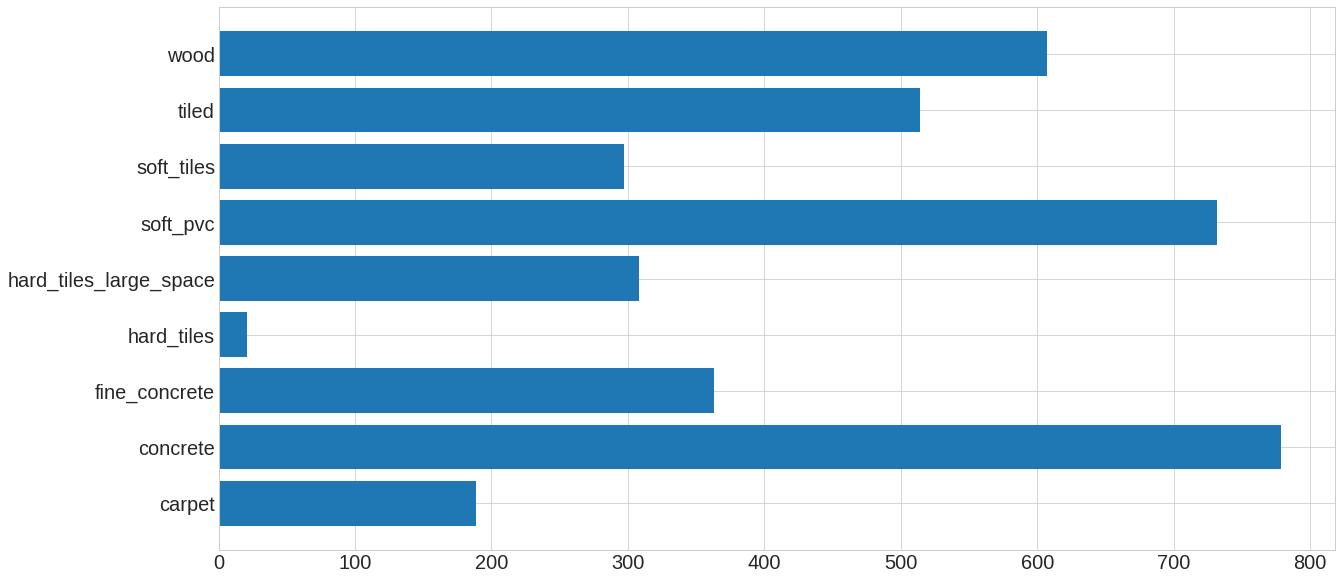

In [90]:
df_count = X_test.groupby(['surface']).count().reset_index()
fig = plt.figure(figsize=(20,10))
plt.rc('font', size = 20)
plt.barh(df_count.surface,df_count.series_id)
plt.legend(loc=1, prop={'size': 16})

In [135]:
X_test.groupby(['surface']).nunique()

,series_id,group_id
surface,,
carpet,189,4
concrete,779,15
fine_concrete,363,7
hard_tiles,21,1
hard_tiles_large_space,308,5
soft_pvc,732,14
soft_tiles,297,6
tiled,514,9
wood,607,12


# Création d'une df pour chaque type de sol 

In [315]:
def surface(df,floor):
  return df[df['surface'] == floor]

def plot_sol(df,id,title):
  fig = plt.figure(figsize=(30, 15))
  floor = df[df['series_id']==id]
  for i, col in enumerate(floor.columns[5:]):
    plt.subplot(3, 4, i + 1)
    plt.plot(floor[col])
    plt.title(col)
  fig.suptitle(title,size = 40)



new_df = pd.merge(X_test[['series_id', 'group_id', 'surface']], X_train, on='series_id')


sol = {'carpet','concret','fine_concrete','hard_tiles','hard_tiles_large_space',
       'soft_pvc','soft_tiles','tiled','wood'}

carpet = surface(new_df,'carpet')
concrete = surface(new_df,'concrete')
fine_concret = surface(new_df,'fine_concrete')
hard_tiles = surface(new_df,'hard_tiles')
hard_tiles_large_space= surface(new_df,'hard_tiles_large_space')
soft_pvc = surface(new_df,'soft_pvc')
soft_tiles = surface(new_df,'soft_tiles')
tiled = surface(new_df,'tiled')
wood = surface(new_df,'wood')

# Visualisation des différents sol 

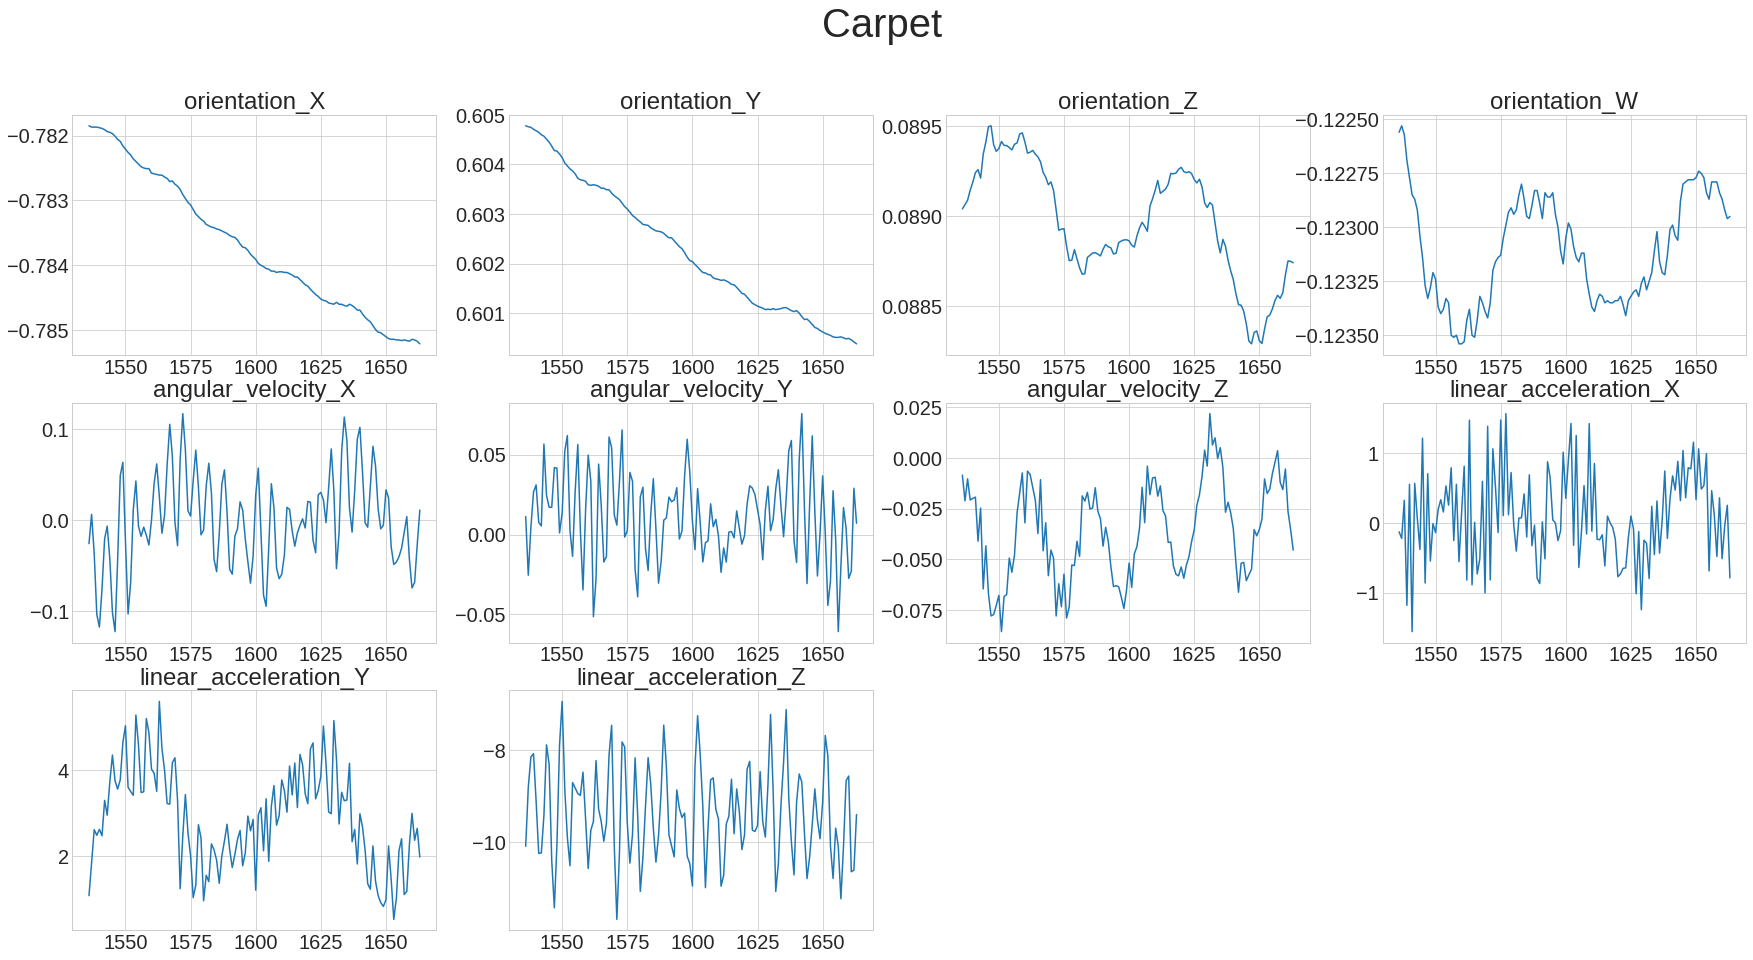

In [316]:
plot_sol(carpet,12,'Carpet')

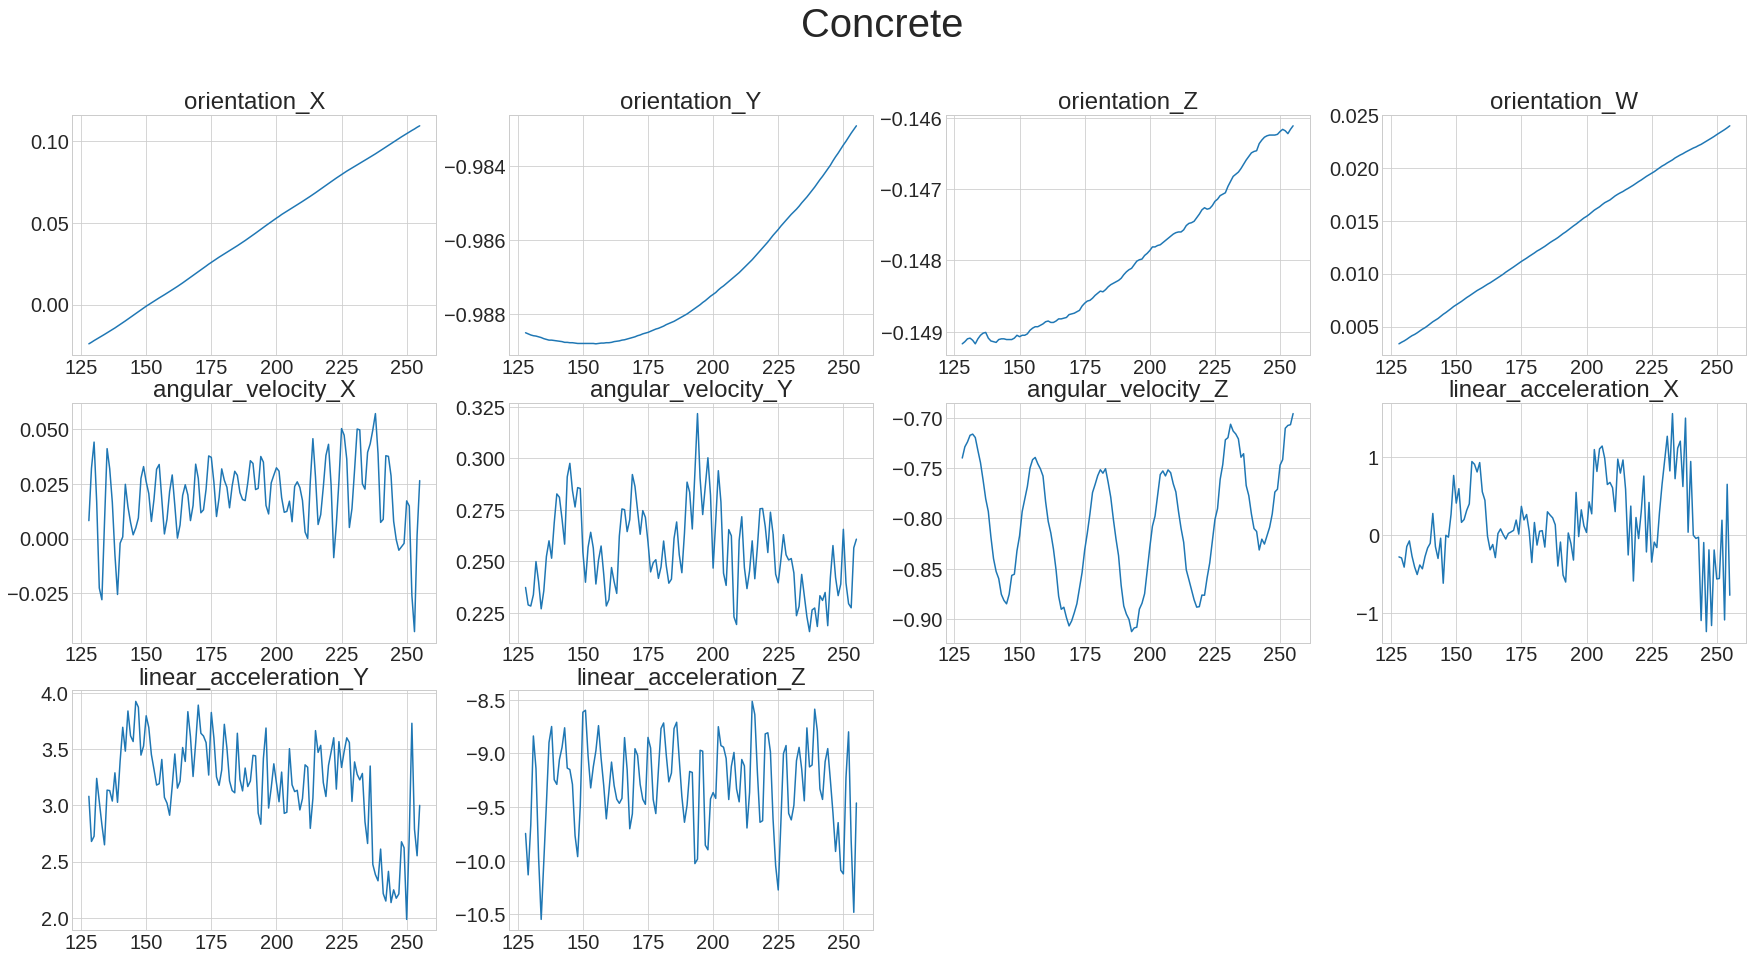

In [317]:
plot_sol(concrete,1,'Concrete')

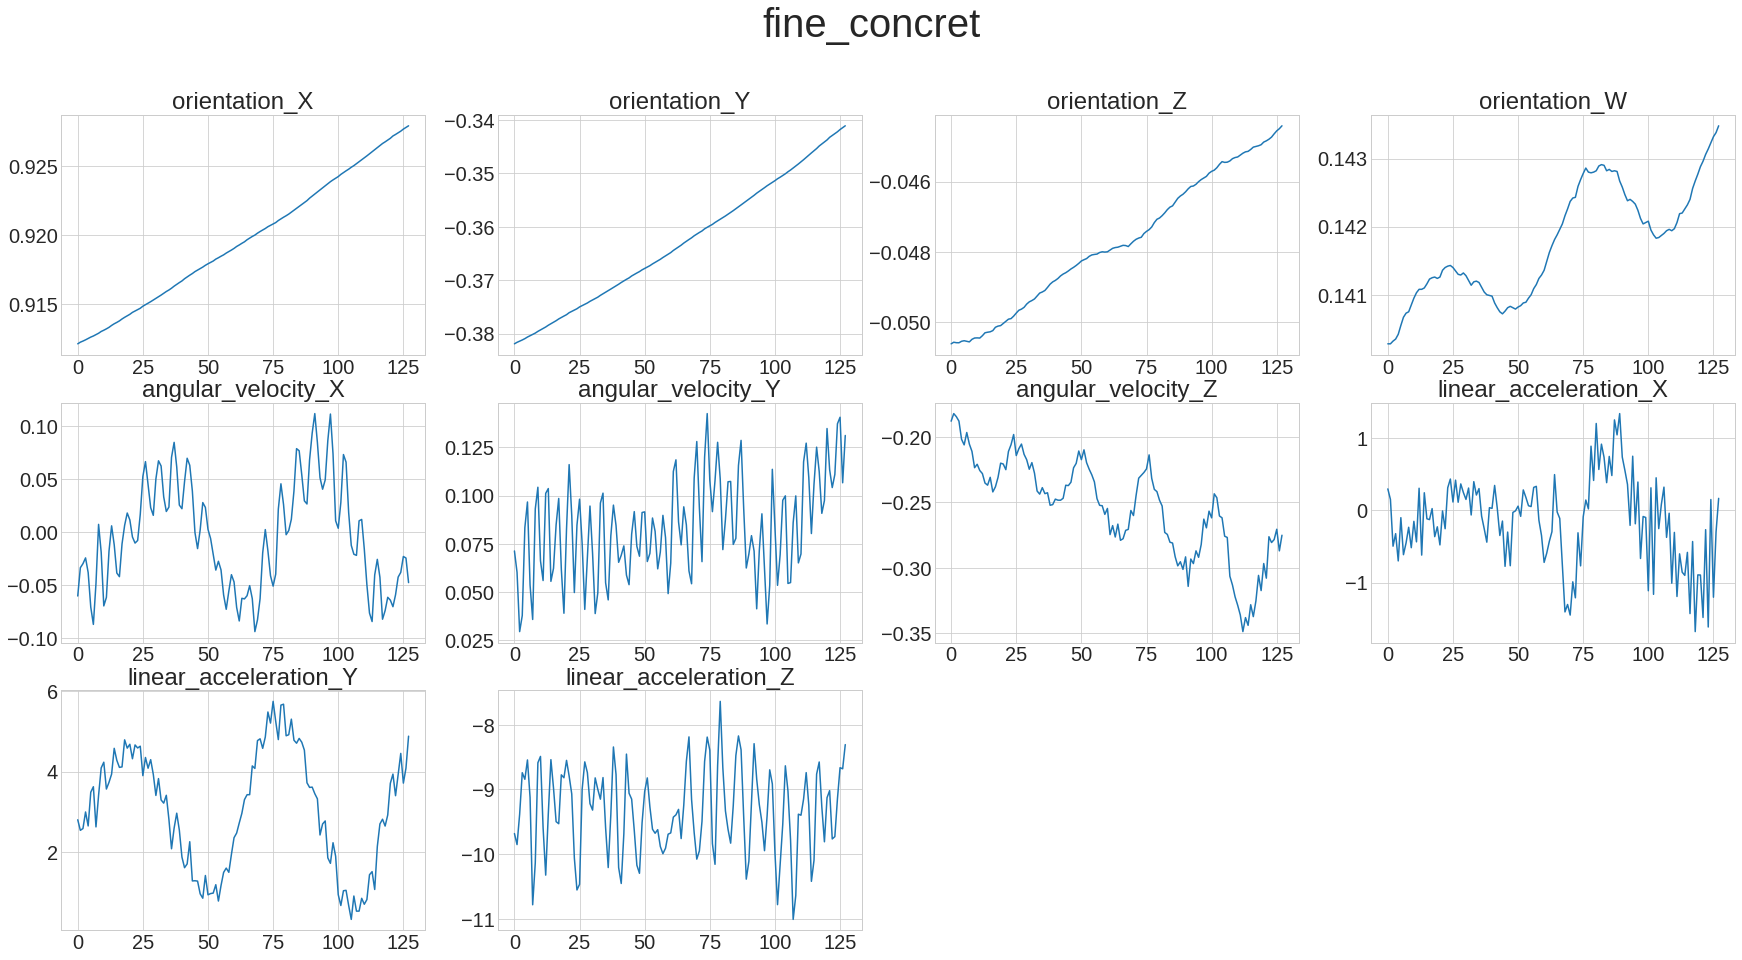

In [318]:
plot_sol(fine_concret,0,'fine_concret')

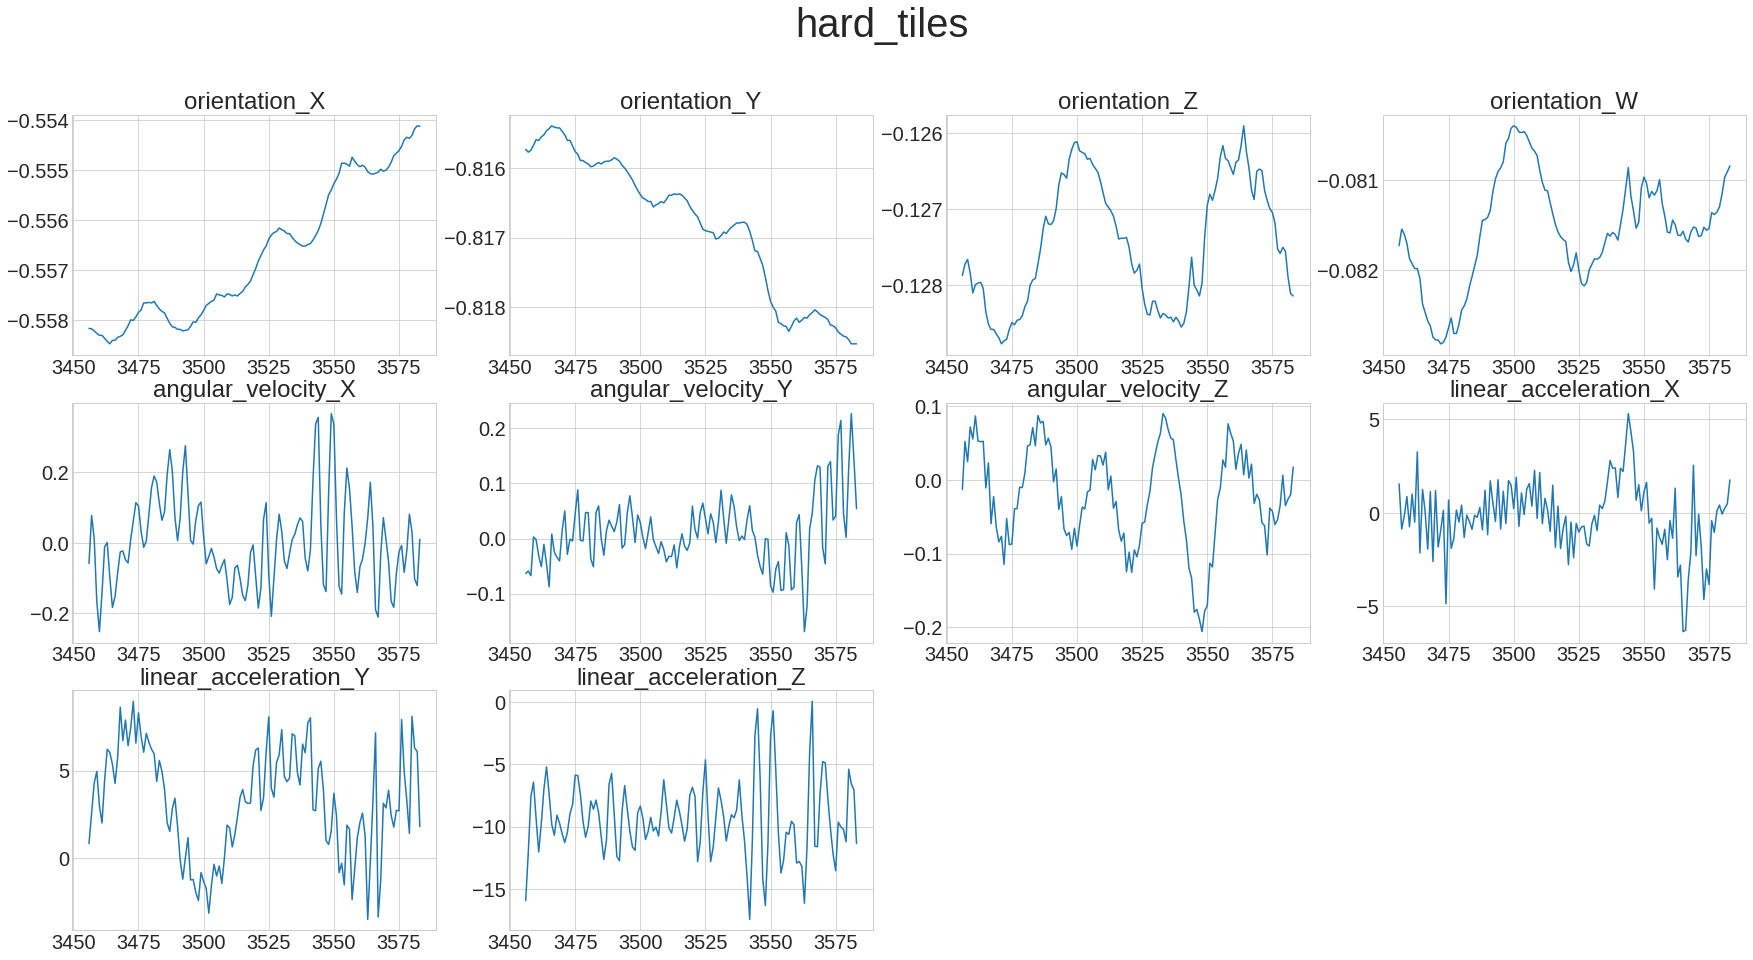

In [319]:
plot_sol(hard_tiles,27,'hard_tiles')

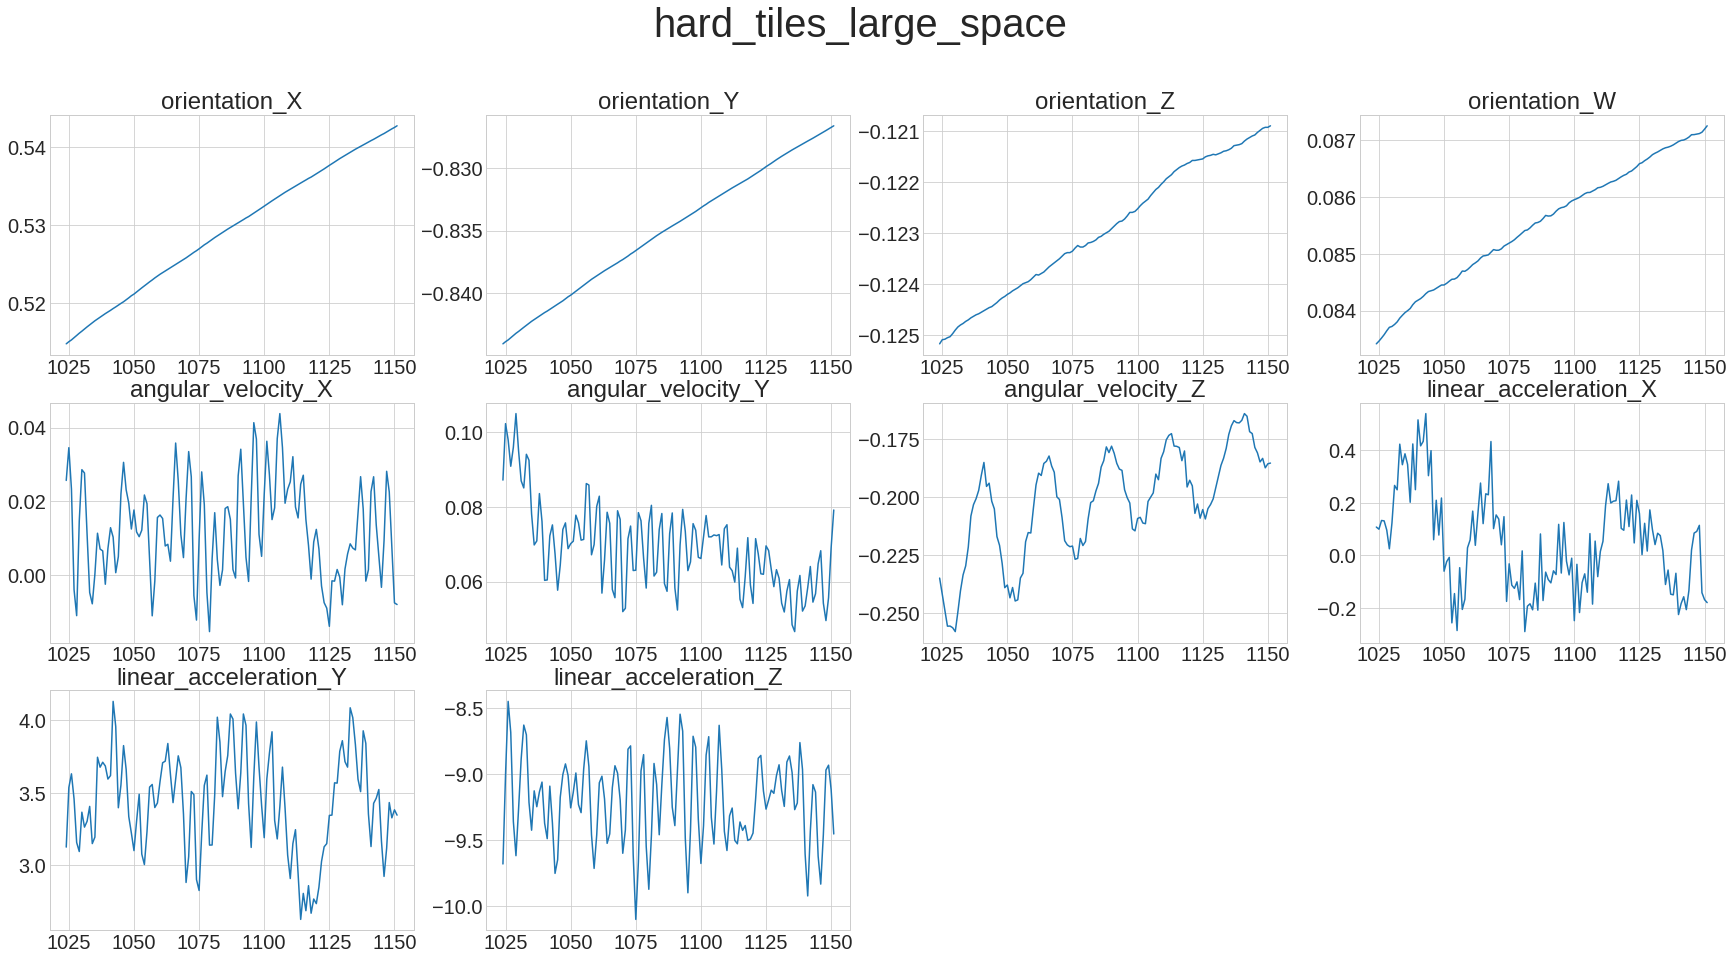

In [320]:
plot_sol(hard_tiles_large_space,8,'hard_tiles_large_space')

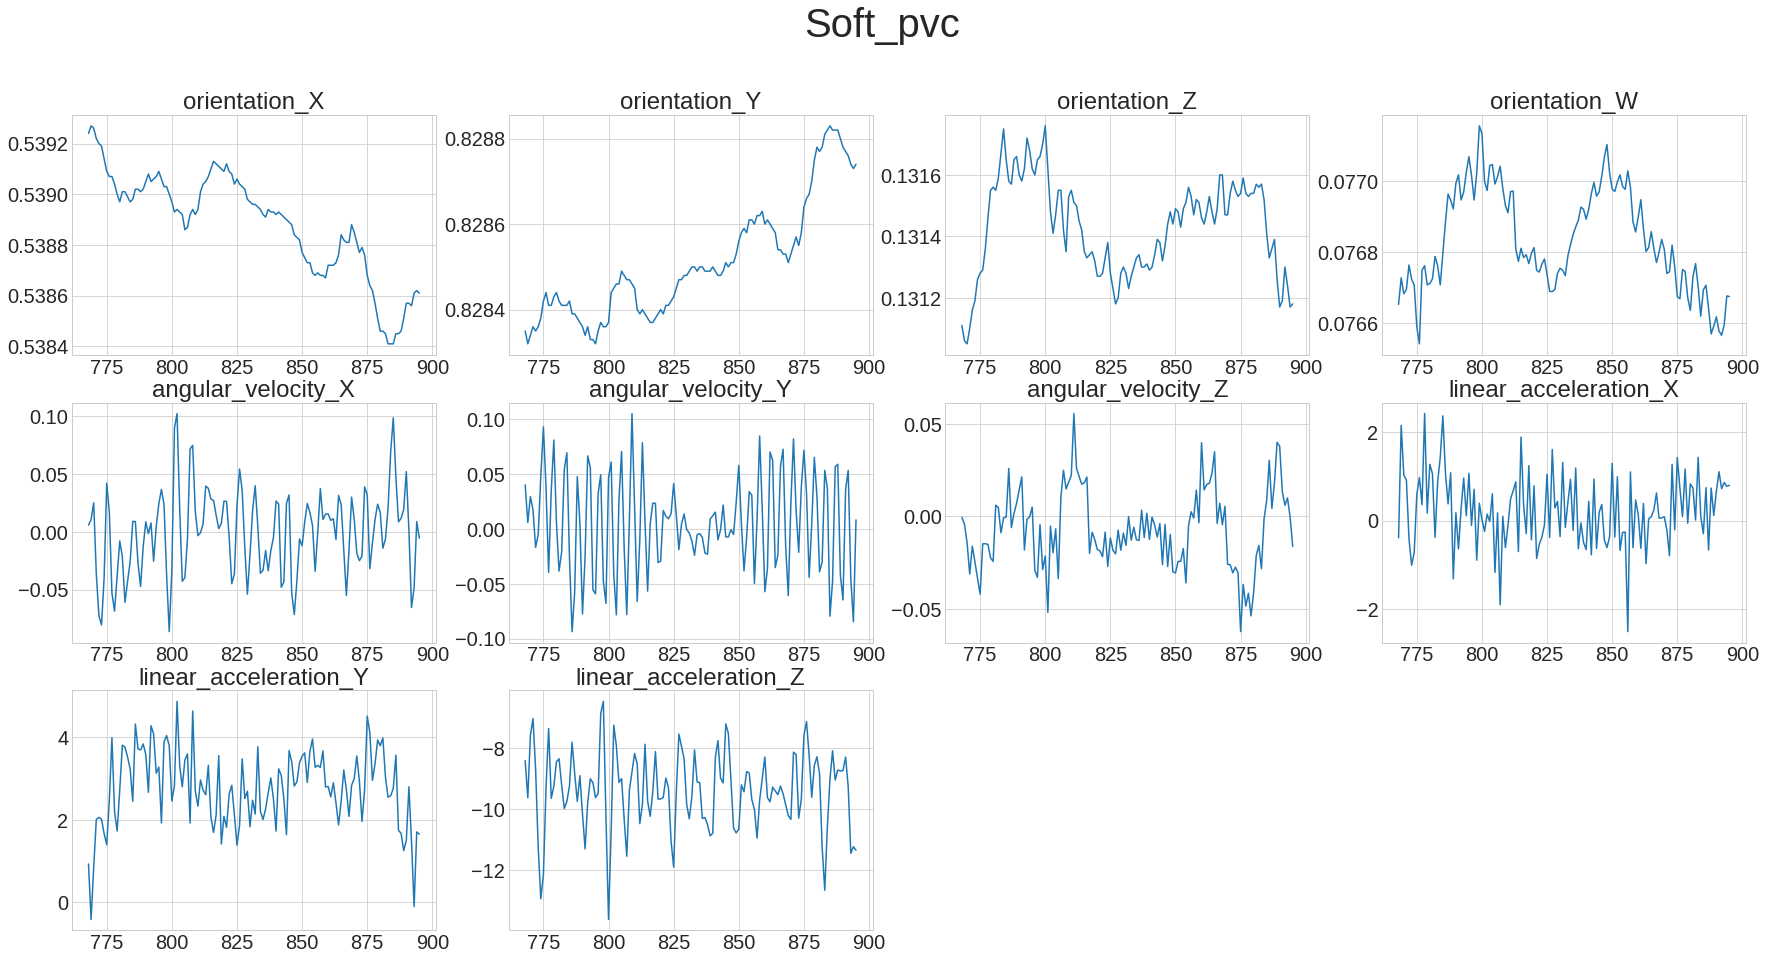

In [321]:
plot_sol(soft_pvc,6,'Soft_pvc')

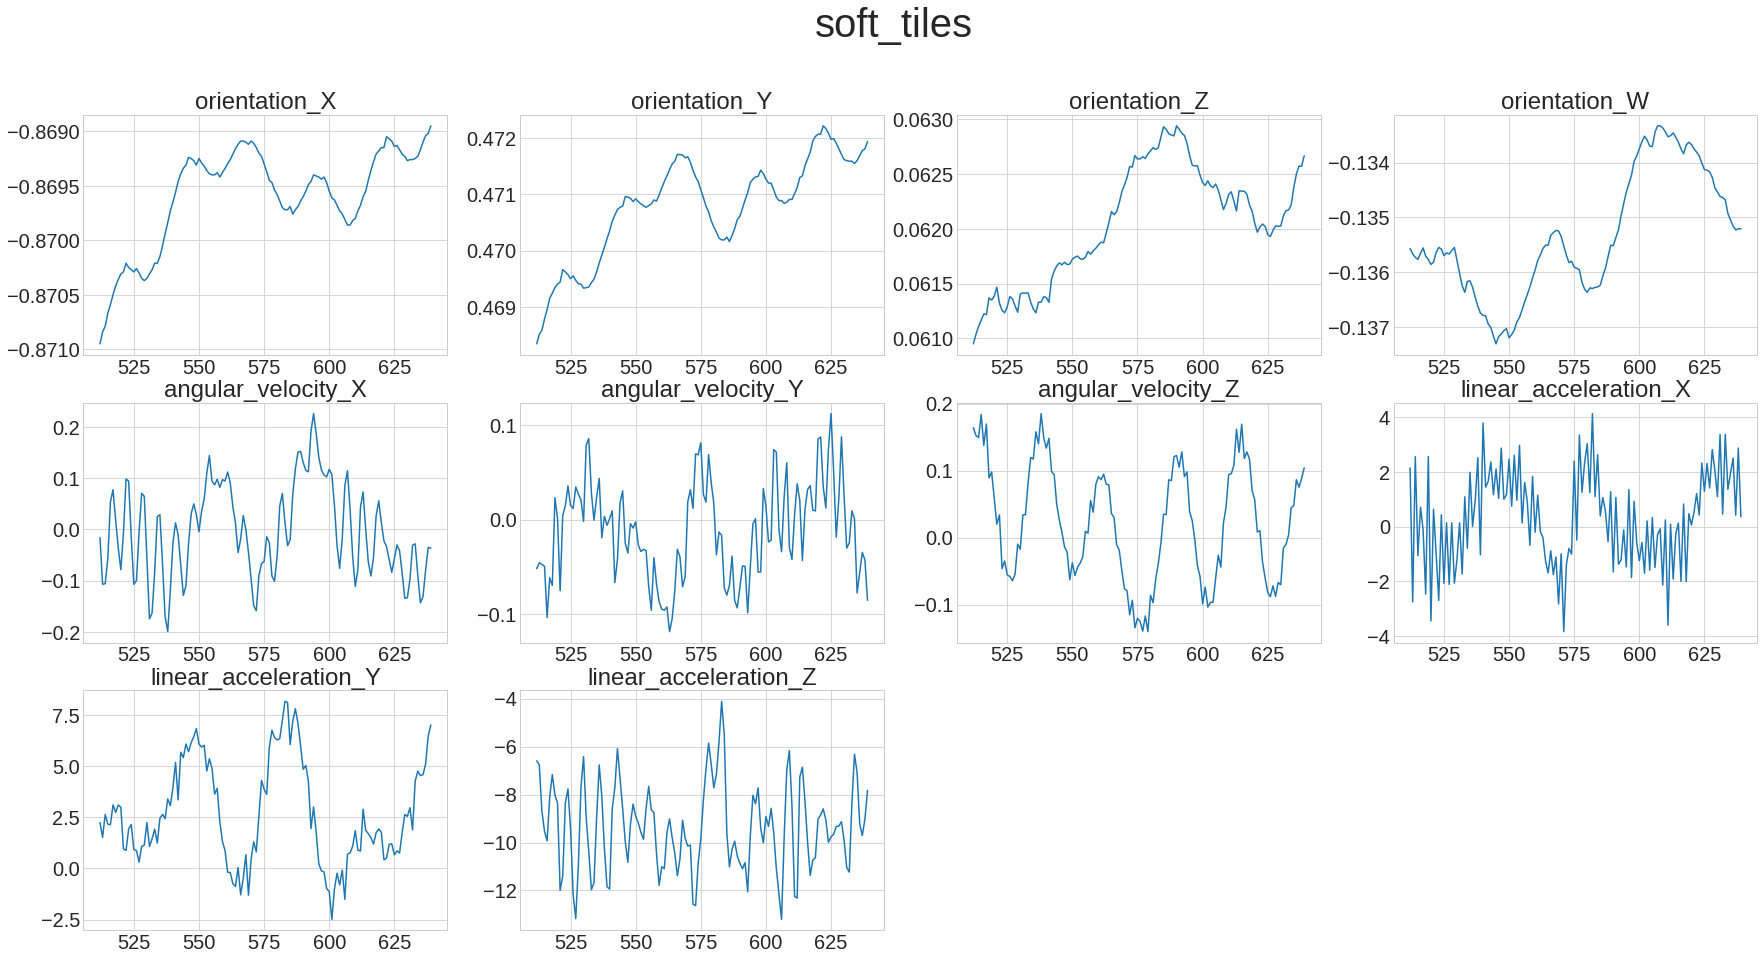

In [322]:
plot_sol(soft_tiles,4,'soft_tiles')

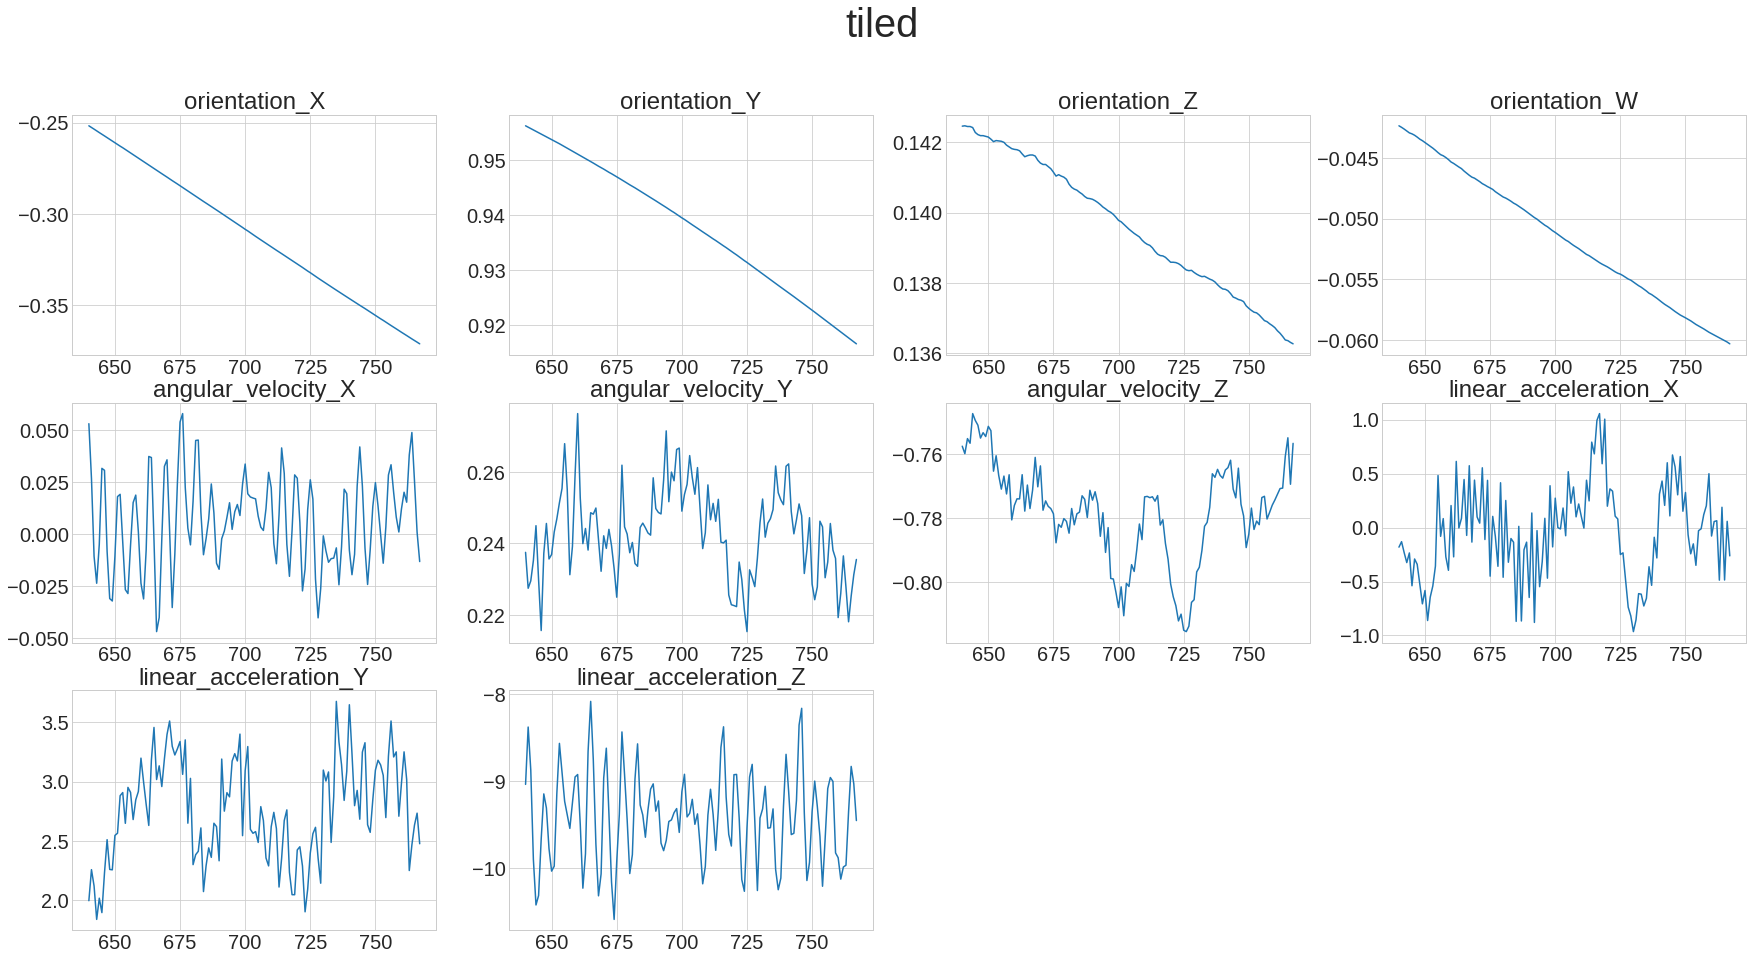

In [323]:
plot_sol(tiled,5,'tiled')

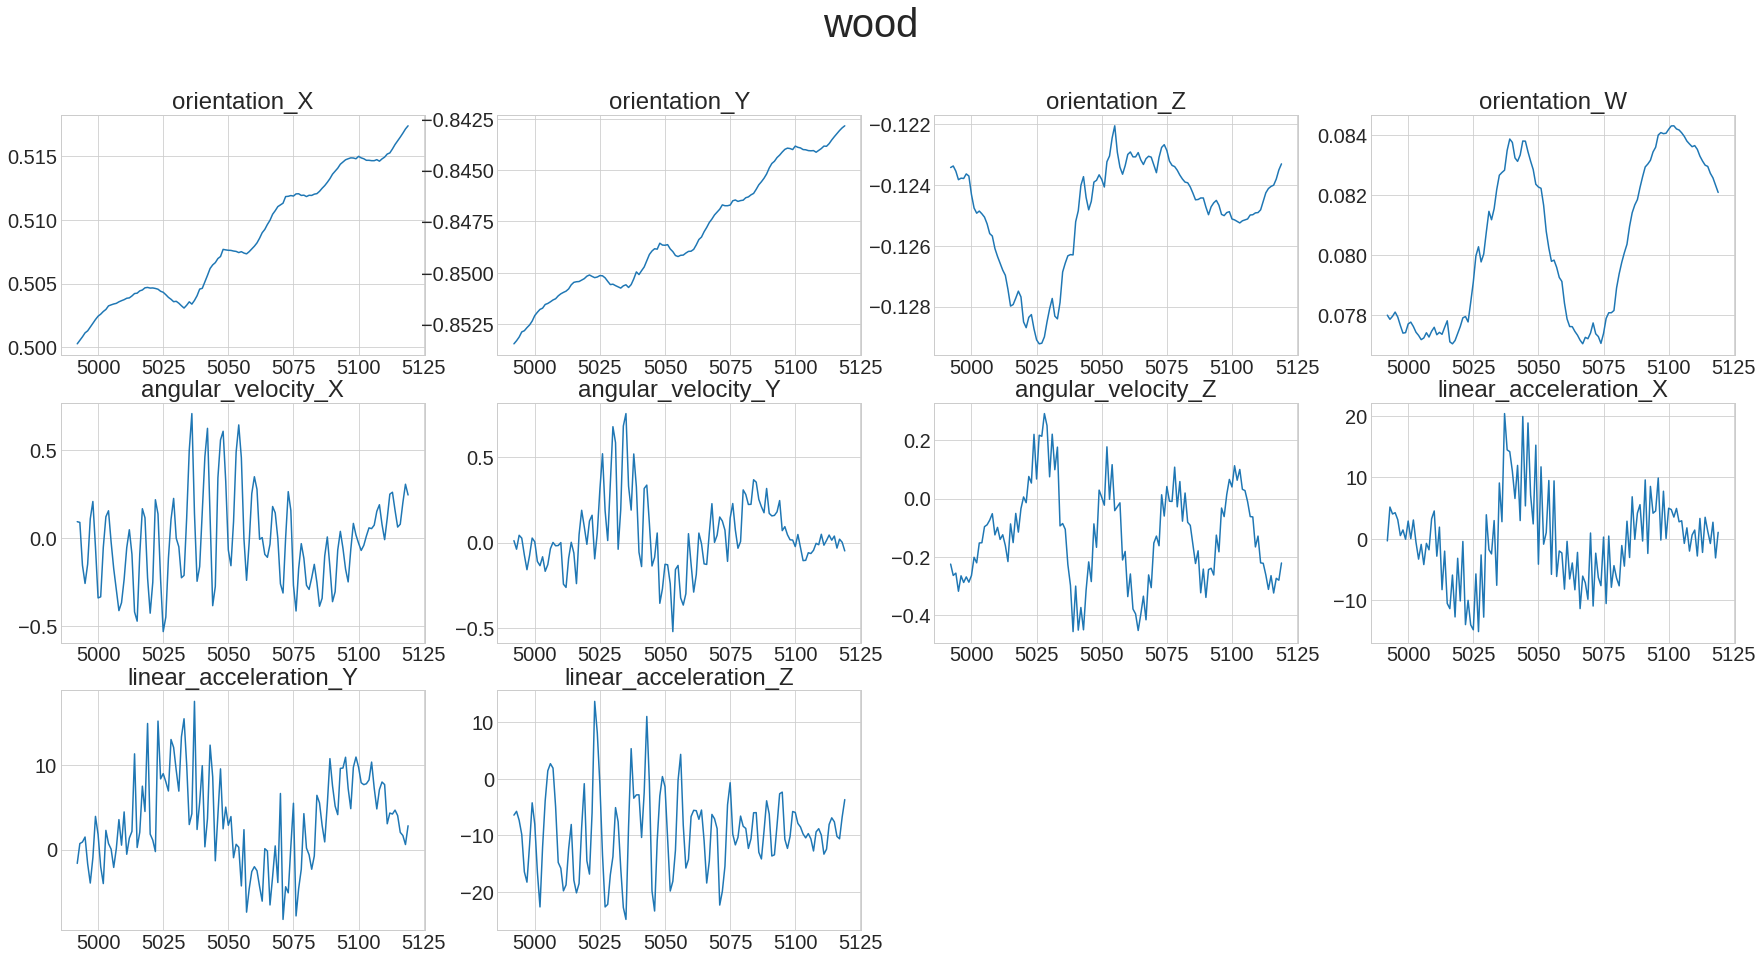

In [324]:
plot_sol(wood,39,'wood')

In [326]:
!git pull

fatal: not a git repository (or any of the parent directories): .git
